In [108]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import time

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

os.chdir('/home/patrick/Python/timeseries/weather/kaggle/Insurance_s4e7')




In [109]:

def prep_data(load_path, save_path, train=True):
    df = pd.read_csv(load_path) 
    print(df.info())

    # Data prep
    # Basic data mod of train data
    df = df.drop(columns=['id'])
    df['Gender'] = df.Gender.replace({"Female":0, 'Male':1}).astype(np.int8)
    df['Vehicle_Age'] = df.Vehicle_Age.replace({'< 1 Year':0, '1-2 Year':1, '> 2 Years':2}).astype(np.int8)
    df['Vehicle_Damage']  = df.Vehicle_Damage.replace({'No':0, 'Yes':1}).astype(np.int8)

    list_int = ['Vehicle_Age','Vintage','Policy_Sales_Channel','Region_Code']
    list_bool = ['Driving_License', 'Previously_Insured', 'Vehicle_Damage', 'Gender']
    list_float32 = ['Annual_Premium','Age']
    list_target = ['Response']

    df[list_int] = df[list_int].astype(np.int32)
    # Optimize integer columns
    if train:
        int_columns = list_int + list_bool + list_target
    else:
        int_columns = list_int + list_bool
        
    for col in int_columns:
        col_min = df[col].min()
        col_max = df[col].max()
        if col_min >= -128 and col_max <= 127:
            df[col] = df[col].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            df[col] = df[col].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            df[col] = df[col].astype(np.int32)

    df[list_float32] = df[list_float32].astype(np.float32)

    print(df.info())
    df.to_parquet(save_path)
    del df
    return 

prep_data('data/raw/train.csv', 'data/artifacts/train.parquet')
# 1+ GB -> 209 MB
#prep_data('data/raw/test.csv', 'data/artifacts/test.parquet', train=False)
# 644 MB -> 132 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11504798 entries, 0 to 11504797
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   Gender                object 
 2   Age                   int64  
 3   Driving_License       int64  
 4   Region_Code           float64
 5   Previously_Insured    int64  
 6   Vehicle_Age           object 
 7   Vehicle_Damage        object 
 8   Annual_Premium        float64
 9   Policy_Sales_Channel  float64
 10  Vintage               int64  
 11  Response              int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 1.0+ GB
None


/tmp/ipykernel_1112/611479651.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df.Gender.replace({"Female":0, 'Male':1}).astype(np.int8)
/tmp/ipykernel_1112/611479651.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Vehicle_Age'] = df.Vehicle_Age.replace({'< 1 Year':0, '1-2 Year':1, '> 2 Years':2}).astype(np.int8)
/tmp/ipykernel_1112/611479651.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.in

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11504798 entries, 0 to 11504797
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Gender                int8   
 1   Age                   float32
 2   Driving_License       int8   
 3   Region_Code           int8   
 4   Previously_Insured    int8   
 5   Vehicle_Age           int8   
 6   Vehicle_Damage        int8   
 7   Annual_Premium        float32
 8   Policy_Sales_Channel  int16  
 9   Vintage               int16  
 10  Response              int8   
dtypes: float32(2), int16(2), int8(7)
memory usage: 208.5 MB
None


In [110]:
def save_small(path_load, path_save):
    
    df = pd.read_parquet(path_load)
    vc = df.Response.value_counts()
    print(vc[1]/vc[0])
    y = df.pop("Response")
    
    Xtrain,_,ytrain,_ = train_test_split(df, y, train_size=int(1e5), stratify=y)
    del df, y
    
    vc = ytrain.value_counts()
    print(vc[1]/vc[0])
    
    df_small = pd.concat([Xtrain, ytrain], axis=1)
    df_small.to_parquet(path_save)
    return

save_small('data/artifacts/train.parquet','data/artifacts/train_small.parquet')

0.14024733444542023
0.1402508551881414


In [111]:
def load_data():
    df = pd.read_parquet('data/artifacts/train_small.parquet')
    display(df.head())

    y = df.pop('Response')

    Xtrain, Xtest, ytrain, ytest = train_test_split(df, y, test_size=0.33, stratify = y)

    # Scale numerical features and split into X,y
    scaler = StandardScaler()
    Xtrain_norm = scaler.fit_transform(Xtrain)
    Xtest_norm = scaler.transform(Xtest)

    # Make Tensors 
    train_norm = torch.FloatTensor(Xtrain_norm)
    test_norm = torch.FloatTensor(Xtest_norm)
    Ytrain = torch.flatten(torch.LongTensor(ytrain.values))
    Ytest = torch.flatten(torch.LongTensor(ytest.values))

    
    return train_norm, test_norm, Ytrain, Ytest, Xtrain, Xtest, ytrain, ytest
    
train_norm, test_norm, Ytrain, Ytest, Xtrain, Xtest, ytrain, ytest = load_data()
  

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
2769934,1,65.0,1,18,0,2,1,60413.0,26,276,1
3692579,0,37.0,1,37,1,1,0,29337.0,124,28,0
11234631,0,22.0,1,28,0,0,1,45420.0,152,165,0
136884,0,37.0,1,36,0,1,1,2630.0,124,105,0
1278403,1,24.0,1,46,1,0,0,27246.0,160,282,0


In [112]:
class Model(nn.Module):
    def __init__(self, in_features, h1=20, h2=30,d_out=2):
        super().__init__()
        
        self.fc1 = nn.Linear(in_features, h1)
        self.relu1 = nn.SiLU()
        self.bn1 = nn.BatchNorm1d(h1)
        self.dp1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(h1, h2)
        self.relu2 = nn.SiLU()
        self.bn2 = nn.BatchNorm1d(h2)
        self.dp2 = nn.Dropout(0.1)

        self.out = nn.Linear(h2,d_out)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.bn1(x)
        x = self.dp1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.bn2(x)
        x = self.dp2(x)
        x = self.out(x)
        return x


In [113]:
def train_fcn(n_epochs, samples_per_batch, lr, Xtrain, Ytrain, Xtest, 
              Ytest, h1,h2, device=None):

    device = torch.device('cuda:0') if torch.cuda.is_available() else 'cpu'

    num_batches = len(Xtrain) // samples_per_batch

    train_loss_hist = []
    test_loss_hist  = []
    
    # Create model class
    in_features = Xtrain.shape[1]
    model = Model(in_features, h1,h2).to(device)
    
    # Set metric (criterion) and choose optimizer
    #class weights for 2 weight = 1-(class no/total no)
    class_no = pd.DataFrame(Ytrain.numpy()).value_counts()
    class_weights = torch.FloatTensor(1 - class_no.values/len(ytrain)).to(device)
    #loss function with class weights
    criterion = nn.CrossEntropyLoss(weight = class_weights) 
    
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)


    Xtrain = Xtrain.to(device)
    Ytrain = Ytrain.to(device)
    Xtest = Xtest.to(device)
    Ytest = Ytest.to(device)
    for epoch in range(n_epochs):

        model.train()
        running_loss = 0.0
        for batch in range(num_batches):

            # Reset
            optimizer.zero_grad()
            # Get a batch
            start = batch * samples_per_batch
            X_batch = Xtrain[start:start+samples_per_batch]
            y_batch = Ytrain[start:start+samples_per_batch]
            # Forward pass
            y_batch_pred = model.forward(X_batch)
            loss = criterion(y_batch_pred, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            # Update weights
            optimizer.step()
            # Compute batch metrics
            running_loss += loss.item()
            
        # Stor batch results
        train_loss_hist.append(running_loss / (batch+1))
        running_loss = 0.0

        # Evaluate training on test set
        model.eval()
        y_test_pred = model.forward(Xtest)
        test_loss = criterion(y_test_pred, Ytest).item()
        
        # Store
        test_loss_hist.append(test_loss)

        if epoch % 10 == 0:
            print(f'Epoch: {epoch} train loss {train_loss_hist[-1]:.4f}, test loss {test_loss:.4f}')
                
    return model, train_loss_hist, test_loss_hist
 
 
n_nodes = Xtrain.shape[1]
h1,h2 = 2*n_nodes, n_nodes
n_epochs = 101
samples_per_batch = 1024
lr = 3e-4

print('Run Training')
modelx, train_loss_hist, test_loss_hist = train_fcn(n_epochs, samples_per_batch, \
            lr, train_norm, Ytrain, test_norm, Ytest, h1,h2)

Run Training
Epoch: 0 train loss 0.6334, test loss 0.5502
Epoch: 10 train loss 0.4675, test loss 0.4447
Epoch: 20 train loss 0.4490, test loss 0.4291
Epoch: 30 train loss 0.4418, test loss 0.4244
Epoch: 40 train loss 0.4391, test loss 0.4222
Epoch: 50 train loss 0.4357, test loss 0.4208
Epoch: 60 train loss 0.4346, test loss 0.4198
Epoch: 70 train loss 0.4339, test loss 0.4191
Epoch: 80 train loss 0.4333, test loss 0.4184
Epoch: 90 train loss 0.4331, test loss 0.4179
Epoch: 100 train loss 0.4320, test loss 0.4174


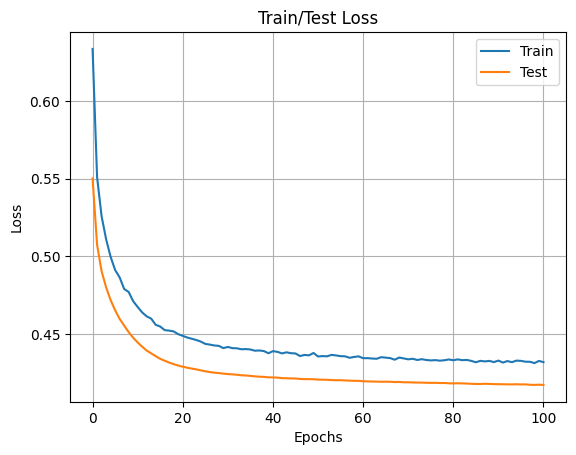

In [114]:
def plot_training(train_loss_hist, test_loss_hist):
    xx = list(range(len(train_loss_hist)))

    plt.figure()
    plt.plot(xx, train_loss_hist, label='Train')
    plt.plot(xx, test_loss_hist, label='Test')
    plt.title('Train/Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

plot_training(train_loss_hist, test_loss_hist)

In [115]:
# Predict test set
modelx.eval()
test_norm = test_norm.to('cuda:0')
y_pred = modelx.forward(test_norm)

print(type(y_pred))
print(y_pred.get_device())
print(y_pred[:10])

<class 'torch.Tensor'>
0
tensor([[ 3.4037, -3.5291],
        [-0.0506,  0.3907],
        [-0.7246,  0.4696],
        [ 2.8529, -2.4539],
        [ 3.2532, -2.6827],
        [-0.6864,  0.4579],
        [-0.8093,  0.4337],
        [ 3.0634, -2.4149],
        [-0.4576,  0.4295],
        [ 3.3920, -3.3529]], device='cuda:0', grad_fn=<SliceBackward0>)


In [116]:
# Get prediction
y_hat = torch.argmax(y_pred, 1).detach().cpu().numpy()
print(y_hat[:10])

[0 1 1 0 0 1 1 0 1 0]


In [117]:
proba_layer = nn.Softmax(dim=1)
y_pred_proba = proba_layer(y_pred)
print(y_pred_proba[:10])
y_pred_proba_arr = y_pred_proba.detach().cpu().numpy()

tensor([[9.9903e-01, 9.7425e-04],
        [3.9143e-01, 6.0857e-01],
        [2.3250e-01, 7.6750e-01],
        [9.9507e-01, 4.9332e-03],
        [9.9736e-01, 2.6357e-03],
        [2.4152e-01, 7.5848e-01],
        [2.2391e-01, 7.7609e-01],
        [9.9584e-01, 4.1591e-03],
        [2.9173e-01, 7.0827e-01],
        [9.9882e-01, 1.1755e-03]], device='cuda:0', grad_fn=<SliceBackward0>)


In [118]:
print(confusion_matrix(ytest, y_hat))
print(classification_report(ytest, y_hat))
print("Accuracy: ", accuracy_score(ytest, y_hat))
print("ROC AUC:", roc_auc_score(ytest, y_pred_proba_arr[:,1]))

[[19050  9891]
 [  211  3848]]
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     28941
           1       0.28      0.95      0.43      4059

    accuracy                           0.69     33000
   macro avg       0.63      0.80      0.61     33000
weighted avg       0.90      0.69      0.75     33000

Accuracy:  0.6938787878787879
ROC AUC: 0.8550818560539768
